In [1]:
#dados instagram oficial do Lula 
#de 1º de janeiro até 5 de julho
#baixei em código json pelo apify
#tem data, tipo(vídeo, carrosel, foto), caption (legenda), curtidas, visualizações, etc.)

In [1]:
import pandas as pd
import requests
import os
from IPython.display import display, Markdown
from tqdm.auto import tqdm # makes pretty progress bars
tqdm.pandas()
from dotenv import load_dotenv
load_dotenv()

C:\Users\larab\.venvs\lede\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
df = pd.read_json('dataset_instagram-scraper_2026-07-06_19-27-37-648.json')
df.head()

,id,type,shortCode,caption,hashtags,mentions,url,commentsCount,firstComment,latestComments,...,originalWidth,audioUrl,alt,ownerFullName,videoDuration,musicInfo,videoPlayCount,locationName,locationId,isPinned
0,3934710268988636297,Video,Daa5iSFJjyJ,Domingo de Brasil na Copa e a gente tá como? C...,[],[],https://www.instagram.com/p/Daa5iSFJjyJ/,2057,👏👏,"[{'id': '18110568949914324', 'text': '👏👏', 'ow...",...,1080,https://scontent-lga3-3.cdninstagram.com/o1/v/...,"Video by Janja Silva on July 05, 2026. May be ...",Janja Silva,57.979,"{'artist_name': 'janjalula', 'song_name': 'Ori...",927567.0,NaN,NaN,NaN
1,3932674735367281188,Video,DaTqtXquFok,Cada quilômetro da Transnordestina que avança ...,[],[ricardostuckert],https://www.instagram.com/p/DaTqtXquFok/,5868,CE APARECE ALGUM JOÃO GUILHERME FICA NA TUA . ...,"[{'id': '17916678930205403', 'text': 'CE APARE...",...,720,https://scontent-hou1-1.cdninstagram.com/o1/v/...,Video by Luiz Inácio Lula da Silva on July 02...,Luiz Inácio Lula da Silva,170.572,"{'artist_name': 'lulaoficial', 'song_name': 'O...",914998.0,NaN,NaN,NaN
2,3931890526354526474,Sidecar,DaQ4ZoHFdEK,R$ 500 milhões para fortalecer a saúde e a edu...,[],[ricardostuckert],https://www.instagram.com/p/DaQ4ZoHFdEK/,733,Se aposente biden 2,"[{'id': '18197358277371107', 'text': 'Se apose...",...,1727,NaN,Photo by Luiz Inácio Lula da Silva on July 01...,Luiz Inácio Lula da Silva,NaN,NaN,NaN,"Alagoinhas, Bahia, Brasil",6.723901e+14,NaN
3,3931993686007483531,Sidecar,DaRP2zBjgyL,Um antigo sonho do povo baiano começa a se con...,[],[ricardostuckert],https://www.instagram.com/p/DaRP2zBjgyL/,7653,Essa não vai ser de container não né Painho?,"[{'id': '18234573769312726', 'text': 'Essa não...",...,1727,NaN,Photo by Luiz Inácio Lula da Silva on July 01...,Luiz Inácio Lula da Silva,NaN,NaN,NaN,Vera cruz,4.493668e+14,NaN
4,3931151268647896312,Sidecar,DaOQUAuFYT4,"Em Assunção, reafirmei que o MERCOSUL é uma ne...",[],[ricardostuckert],https://www.instagram.com/p/DaOQUAuFYT4/,1240,Gente inteligente = Lula presidente #genteinte...,"[{'id': '18346981435174455', 'text': 'Gente in...",...,1727,NaN,Photo by Luiz Inácio Lula da Silva on June 30...,Luiz Inácio Lula da Silva,NaN,NaN,NaN,Assunção - Paraguai,8.720597e+08,NaN


In [ ]:
#tem alguma publicação com legenda em BRANCO?

In [3]:
df[df['caption'].str.strip() == '']

,id,type,shortCode,caption,hashtags,mentions,url,commentsCount,firstComment,latestComments,...,originalWidth,audioUrl,alt,ownerFullName,videoDuration,musicInfo,videoPlayCount,locationName,locationId,isPinned


In [4]:
df.shape

(311, 37)

In [5]:
df.columns

Index(['id', 'type', 'shortCode', 'caption', 'hashtags', 'mentions', 'url',
       'commentsCount', 'firstComment', 'latestComments', 'dimensionsHeight',
       'dimensionsWidth', 'displayUrl', 'images', 'videoUrl', 'likesCount',
       'videoViewCount', 'timestamp', 'childPosts', 'ownerUsername', 'ownerId',
       'productType', 'taggedUsers', 'coauthorProducers', 'isCommentsDisabled',
       'inputUrl', 'originalHeight', 'originalWidth', 'audioUrl', 'alt',
       'ownerFullName', 'videoDuration', 'musicInfo', 'videoPlayCount',
       'locationName', 'locationId', 'isPinned'],
      dtype='str')

In [6]:
#clean the data
#how to drop columns we don't need
#drop(columns=['x', 'y'], inplace=True)

In [7]:
df_clean = df.drop(columns=['dimensionsHeight', 'videoDuration', 'displayUrl', 'mentions', 'locationName', 'videoViewCount','isPinned', 'images', 'taggedUsers', 'firstComment', 'latestComments', 'videoPlayCount','inputUrl', 'coauthorProducers','productType','locationId','dimensionsWidth', 'musicInfo', 'originalWidth', 'shortCode', 'originalHeight', 'videoUrl','shortCode', 'hashtags', 'childPosts', 'ownerUsername', 'ownerId', 'audioUrl', 'alt', 'ownerFullName'])
df_clean.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'isCommentsDisabled'],
      dtype='str')

In [8]:
df_clean.head()

,id,type,caption,url,commentsCount,likesCount,timestamp,isCommentsDisabled
0,3934710268988636297,Video,Domingo de Brasil na Copa e a gente tá como? C...,https://www.instagram.com/p/Daa5iSFJjyJ/,2057,64546,2026-07-05 18:02:43+00:00,False
1,3932674735367281188,Video,Cada quilômetro da Transnordestina que avança ...,https://www.instagram.com/p/DaTqtXquFok/,5868,75341,2026-07-02 22:31:57+00:00,False
2,3931890526354526474,Sidecar,R$ 500 milhões para fortalecer a saúde e a edu...,https://www.instagram.com/p/DaQ4ZoHFdEK/,733,13185,2026-07-01 20:31:37+00:00,False
3,3931993686007483531,Sidecar,Um antigo sonho do povo baiano começa a se con...,https://www.instagram.com/p/DaRP2zBjgyL/,7653,124574,2026-07-01 23:56:35+00:00,False
4,3931151268647896312,Sidecar,"Em Assunção, reafirmei que o MERCOSUL é uma ne...",https://www.instagram.com/p/DaOQUAuFYT4/,1240,24898,2026-06-30 20:02:51+00:00,False


In [9]:
len(df_clean.columns)

8

In [10]:
#311 publicações.
#tem alguma que é nula?

In [11]:
df_clean.isnull().sum()

id                    0
type                  0
caption               0
url                   0
commentsCount         0
likesCount            0
timestamp             0
isCommentsDisabled    0
dtype: int64

In [12]:
#nenhum id é nulo, então, são realmente 311 publicações. 

In [13]:
#Timestamp > é a coluna com data e horário > quero só o mês.> mas antes quero confirmar que só tem o ano de 2026.

In [14]:
df_clean['date'] = df_clean['timestamp'].dt.date
df_clean['date']

0      2026-07-05
1      2026-07-02
2      2026-07-01
3      2026-07-01
4      2026-06-30
          ...    
306    2026-01-14
307    2026-01-17
308    2026-01-18
309    2026-02-24
310    2026-02-28
Name: date, Length: 311, dtype: object

In [15]:
#transforma em dt.

In [16]:
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean["date"]

0     2026-07-05
1     2026-07-02
2     2026-07-01
3     2026-07-01
4     2026-06-30
         ...    
306   2026-01-14
307   2026-01-17
308   2026-01-18
309   2026-02-24
310   2026-02-28
Name: date, Length: 311, dtype: datetime64[s]

In [17]:
#checar se todos são de 2026 antes de separar só por mÊs > realmente só tem 2026.

In [18]:
df_clean['date'].dt.year.unique()

array([2026], dtype=int32)

In [19]:
#agora sim: criar uma coluna só de mês.

In [20]:
df_clean['month'] = df_clean['date'].dt.month
df_clean['month']

0      7
1      7
2      7
3      7
4      6
      ..
306    1
307    1
308    1
309    2
310    2
Name: month, Length: 311, dtype: int32

In [21]:
#número de posts por mês > como cada aparição é um post > dá pra ver pelo número de linhas

In [22]:
posts_month = df_clean['month'].value_counts(ascending=True)
posts_month

month
7    10
1    44
5    46
3    48
2    52
6    55
4    56
Name: count, dtype: int64

In [23]:
posts_month.mean()

np.float64(44.42857142857143)

In [24]:
# Lula publicou cerca de 44 posts por mês entre 1 de janeiro e 5 de julho de 2026.

In [25]:
#abril foi o mês com mais publicações > com 56 posts.

In [26]:
posts_month.idxmax(), posts_month.max()

(np.int32(4), np.int64(56))

<Axes: ylabel='month'>

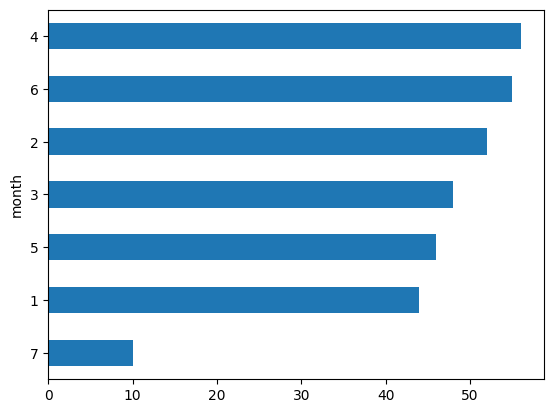

In [27]:
posts_month.plot(kind='barh')

In [28]:
#quantas publicações com os comentários desabilitados? > nenhuma.

In [29]:
df_clean['isCommentsDisabled'].value_counts()

isCommentsDisabled
False    311
Name: count, dtype: int64

In [30]:
#então tira essa coluna pra ficar mais limpo

In [31]:
df_clean_2 = df_clean.drop(columns=['isCommentsDisabled'])
df_clean_2.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'date', 'month'],
      dtype='str')

In [34]:
df_clean_2['caption'].isna().sum()

np.int64(0)

In [32]:
df_clean_2['caption'].isnull().sum()

np.int64(0)

In [32]:
#número total de comentários > 2.308.080
#média de comentários por post. > 7.421
#quais os top5 com mais comentários. > top5_com_posts

In [33]:
#5 posts mais comentados.
#1 teve 59120 comentários

In [34]:
total_com = df_clean['commentsCount'].sum()
total_com

np.int64(2308080)

In [35]:
media_com_post= 2308080/311
round(media_com_post,2)

7421.48

In [36]:
top5_com_posts = df_clean.sort_values(by='commentsCount', ascending=False).head(5)
top5_com_posts

,id,type,caption,url,commentsCount,likesCount,timestamp,isCommentsDisabled,date,month
159,3870661425575475852,Video,O Brasil é o único país do mundo com mais de 1...,https://www.instagram.com/p/DW3Wg8VO7qM/,59120,705815,2026-04-08 09:00:00+00:00,False,2026-04-08,4
36,3918527150415323762,Video,Professor Carlo Ancelotti e jogadores da nossa...,https://www.instagram.com/p/DZhZ66bOqJy/,57903,961319,2026-06-13 10:00:15+00:00,False,2026-06-13,6
288,3833950534772887106,Video,"Uma noite inesquecível na Sapucaí. Niterói, Im...",https://www.instagram.com/p/DU07bK_jo5C/,43661,602733,2026-02-16 17:29:19+00:00,False,2026-02-16,2
84,3891971608475424346,Sidecar,Reunião muito produtiva com o presidente dos E...,https://www.instagram.com/p/DYDD46vFVZa/,40028,737799,2026-05-07 18:39:52+00:00,False,2026-05-07,5
268,3810595561460898767,Video,"Conheci o Douglas, filho de diarista e de pedr...",https://www.instagram.com/p/DTh9HlHjpvP/,38081,456001,2026-01-15 12:00:00+00:00,False,2026-01-15,1


In [37]:
#152 carroséis, 123 vídeos e 36 fotos únicas.

In [38]:
type_lula = df['type'].value_counts()
type_lula 

type
Sidecar    152
Video      123
Image       36
Name: count, dtype: int64

In [39]:
###CLASSIFICAÇÃO: DO QUE OS POSTS MAIS FALAM?
#NORDESTE? (BAHIA, ALAGOAS, CEARÁ,Salvador )
#COPA DO MUNDO?
#CULTURA > OSCAR, CINEMA, FILMES, Festival
#EDUCAÇÃO > Prouni, Universidade
#ECONOMIA > MERCOSUL,
#PROGRAMAS DO PT, PT >  Minha Casa, Minha Vida
#OUTROS

In [40]:
df['caption'].value_counts()

caption
Domingo de Brasil na Copa e a gente tá como? Colando figurinha no álbum desse outro craque 😍⚽️ Com direito a comentários especiais!\n\nE sabe o mais legal? Você também pode colecionar o álbum! Acesse o link que tá nos stories para baixar e relembrar a história do presidente Lula.\n\nCompartilhe com quem também joga pelo Brasil! 💛🇧🇷\n\n🔗 https://pt.org.br/link/crebkm1sif9hava                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   1
Cada quilômetro da Transnordestina que avança leva

In [41]:
#criar uma amostra de 20% do meu df 
#crio uma coluna vazia com nome 'groundtruth' > pode ser outro.
#e salvo como excel
#verifico e salvo como handcoded.csv

In [42]:
data_sample = df_clean_2.set_index("url").sample(frac=0.2, random_state=42)
data_sample.shape

(62, 8)

In [43]:
data_sample["groundtruth"] = ""
data_sample.to_csv("lula_posts_for_hand_classification.csv")

In [44]:
#importar a IA
### setting up our connection to an API client for an AI provider

In [45]:
USE_OPENROUTER=True

from anthropic import Anthropic

if USE_OPENROUTER:
  from openrouter import OpenRouter
else:
  from openai import OpenAI
  from mistralai.client import Mistral

if USE_OPENROUTER:
  openrouter_client = OpenRouter(api_key=os.environ.get("OPENROUTER_API_KEY_LEDE"))
else:
  openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY_LEDE"))
  mistral_client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY_LEDE"))
anthropic_client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY_LEDE"),) # intentionally created outside of the if; we'll use anthropic_client to count tokens (even if we're using openrouter)


In [46]:
#criar o prompt base
#definir categorias

In [47]:
prompt_base = """
Você é um classificador de posts de Instagram do presidente Lula. Leia o post abaixo e
escolha a ÚNICA categoria que melhor descreve o TEMA PRINCIPAL do post, dentre estas
opções: {categories}

Guia de categorias, com exemplos de posts que se encaixam em cada uma:

- politicas_sociais: programas habitacionais (Minha Casa, Minha Vida), educação
  (escolas, universidades, bolsas de estudo, Prouni), saúde (SUS, hospitais, vacinação), 
  ou desenrola (que ajuda brasileiro envididados),
  Exemplo: "Hoje entreguei as chaves de mais 500 casas do Minha Casa, Minha Vida."
  Exemplo: "O SUS oferece atendimento gratuito e universal para todos os brasileiros."

- economia_producao: agronegócio (Amazônia, fertilizantes, produção agrícola,
  exportação de commodities), combustíveis e energia (preço da gasolina, diesel,
  petróleo), tecnologia (como IA), acordo entre União Europei e Merosul (que é economico). 
  Exemplo: "Investir em fertilizantes é investir em soberania alimentar."
  Exemplo: "Reduzimos o preço do diesel para o caminhoneiro brasileiro."

- governo_instituicoes: balanço geral da gestão do governo atual ("nosso governo",
  "nossa gestão"), temas ligados à democracia e às instituições (Judiciário, STF, os
  três poderes), ou política externa (menção a outros países, viagens internacionais,
  reuniões com líderes estrangeiros, acordos internacionais).
  ONU, Estados Unidos, etc. > usa palavras como soberania, democracia, etc.
  Exemplo: "Nosso governo já gerou resultados que o povo pode sentir no dia a dia."
  Exemplo: "Ótima reunião com o presidente dos Estados Unidos na Casa Branca."

- cultura_regionalidade: cultura em geral (filmes, Oscar, cinema, música, Carnaval) ou
  posts com foco no Nordeste (Bahia, Salvador, ou qualquer estado nordestino).
  Exemplo: "Uma noite inesquecível na Sapucaí, com escolas de samba de tirar o fôlego."
  Exemplo: "Visita emocionante a Salvador, terra de tanta cultura e resistência."

- outros: futebol (incluindo Copa do Mundo e resultados de jogos), datas comemorativas pessoais, ou qualquer assunto que não se encaixe
  claramente nas categorias acima.

Retorne apenas o nome da categoria, exatamente como escrito acima, nada mais.

Aqui está o post: {tweet_text}
"""

In [48]:
#define as categorias

In [49]:
from enum import Enum, IntEnum

class LulaPostOptions(str, Enum):
    politicas_sociais = "politicas_sociais"
    economia_producao = "economia_producao"
    governo_instituicoes = "governo_instituicoes"
    cultura_regionalidade = "cultura_regionalidade"
    outros = "outros"

In [50]:
from pydantic import BaseModel

class LulaPostValidOptions(BaseModel):
    classification: LulaPostOptions

In [51]:
#cria a coluna com a resposta do prompt.

In [52]:
data_sample_prompt_column = data_sample.apply(
    lambda row: prompt_base.format(
        tweet_text=row["caption"],
        categories=", ".join(['"{}"'.format(opt.value) for opt in LulaPostOptions])
    ),
    axis="columns"
)

In [53]:
#mandar para a IA classificar pelo OpenRouter > o return é a resposta do prompt.

In [54]:
def classify(prompt):
    response = openrouter_client.chat.send(
        model="openai/gpt-5.5",
        messages=[{"role": "user", "content": prompt}],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "lula_post_classification",
                "strict": True,
                "schema": LulaPostValidOptions.model_json_schema(),
            },
        },
    )
    return LulaPostValidOptions.model_validate_json(
        response.choices[0].message.content
    ).classification.value


In [55]:
data_sample["ai_guess"] = data_sample_prompt_column.progress_apply(classify)

100%|██████████| 62/62 [03:17<00:00,  3.18s/it]


In [56]:
# confere se realmente criou essa coluna e se é do mesmo tamanho da que eu conferi manualmente.
#aqui é só o sample com uma coluna com as respostas da IA.

In [57]:
data_sample["ai_guess"].shape

(62,)

In [58]:
## IMPORTAR CSV MANUAL E COMPARAR COM RESULTADO DA IA

In [59]:
handcoded = pd.read_csv("handcoded.lula.csv").set_index("url")
handcoded.head()

,id,type,caption,commentsCount,likesCount,timestamp,groundtruth
url,,,,,,,
https://www.instagram.com/p/DT-lavjjnfS/,3818654099546470354,Video,Você já parou para pensar no que passa pela ca...,2191,14038,2026-01-26 14:52:46+00:00,politicas_sociais
https://www.instagram.com/p/DaBMJB3lZZo/,3927473747083499112,Sidecar,Investir em produção de fertilizantes é invest...,887,12187,2026-06-25 18:16:16+00:00,economia_producao
https://www.instagram.com/p/DY7ApnHOjDX/,3907719961169768663,Video,A educação é o único caminho capaz de transfor...,13508,214890,2026-05-29 12:13:23+00:00,politicas_sociais
https://www.instagram.com/p/DY5uDi1DlVt/,3907356705415910765,Sidecar,Hoje vivi um momento histórico para o Brasil. ...,1173,16392,2026-05-29 00:07:18+00:00,politicas_sociais
https://www.instagram.com/p/DZ8BnIwFuTy/,3926020062663075058,Video,Recado do dia e um desafio para vocês. Façam a...,2747,26847,2026-06-23 18:10:09+00:00,governo_instituicoes


In [60]:
#juntar coluna ai guess no meu handcoded

In [61]:
#pede para comparar a acurácia do que eu fiz com a IA

In [62]:
#Conferindo se a coluna ai_guess está no handcoded

In [63]:
if "groundtruth" not in handcoded.columns:
  print("uh oh, your handcoded.csv doesn't have a column named groundtruth")
  assert "groundtruth" in handcoded.columns
if handcoded.groundtruth.isna().any() or (handcoded.groundtruth == '').any():
  print("uh oh, there are some blanks in your handcoded.csv's groundtruth column. go fix that!")

# if the ai_guess column got lost in the process... we'll grab it again
if "ai_guess" not in handcoded:
  handcoded = handcoded.merge(data_sample[["ai_guess"]], right_index=True, left_index=True, how="left")

In [64]:
#dá uma checada para ver se as duas colunas (groudtruth e ia guess estão completadas)

In [65]:
handcoded.head()

,id,type,caption,commentsCount,likesCount,timestamp,groundtruth,ai_guess
url,,,,,,,,
https://www.instagram.com/p/DT-lavjjnfS/,3818654099546470354,Video,Você já parou para pensar no que passa pela ca...,2191,14038,2026-01-26 14:52:46+00:00,politicas_sociais,politicas_sociais
https://www.instagram.com/p/DaBMJB3lZZo/,3927473747083499112,Sidecar,Investir em produção de fertilizantes é invest...,887,12187,2026-06-25 18:16:16+00:00,economia_producao,economia_producao
https://www.instagram.com/p/DY7ApnHOjDX/,3907719961169768663,Video,A educação é o único caminho capaz de transfor...,13508,214890,2026-05-29 12:13:23+00:00,politicas_sociais,politicas_sociais
https://www.instagram.com/p/DY5uDi1DlVt/,3907356705415910765,Sidecar,Hoje vivi um momento histórico para o Brasil. ...,1173,16392,2026-05-29 00:07:18+00:00,politicas_sociais,politicas_sociais
https://www.instagram.com/p/DZ8BnIwFuTy/,3926020062663075058,Video,Recado do dia e um desafio para vocês. Façam a...,2747,26847,2026-06-23 18:10:09+00:00,governo_instituicoes,politicas_sociais


In [66]:
### sempre verificar se as categorias que vc colocou 
#no prompt são as mesmas e escritas igual nas que vc definiiu!! se não, dá ruim!!

In [67]:
from sklearn.metrics import accuracy_score
display(Markdown("Accuracy score: {:.1%}. Is that good?".format(
    accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
)))

Accuracy score: 83.9%. Is that good?

In [68]:
#good enought. 

In [69]:
#se estiver aceitável, peça para a AI classificar todos os posts.

In [70]:
#assuntos mais postados por mês.

In [72]:
## criando a coluna de prompt para o dataset completo
# usando o prompt_base mais recente (com as categorias guarda-chuva)
data_full_prompt_column = df_clean_2.apply(
    lambda row: prompt_base.format(
        tweet_text=row["caption"],
        categories=", ".join(['"{}"'.format(opt.value) for opt in LulaPostOptions])
    ),
    axis="columns"
)

In [73]:
df_clean_2.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'date', 'month'],
      dtype='str')

In [74]:
df_clean_2["timestamp"] = pd.to_datetime(df_clean_2["timestamp"])

In [76]:
data_dir = "./"

In [77]:
print(data_dir)

./


In [78]:
## classificando o dataset completo
df_clean_2["ai_guess"] = data_full_prompt_column.progress_apply(classify)

df_clean_2.to_csv(data_dir + "lula_posts_ai_classified.csv")

100%|██████████| 311/311 [19:06<00:00,  3.69s/it]


In [79]:
df_clean_2["ai_guess"].shape

(311,)

In [81]:
df_clean_2.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'date', 'month', 'ai_guess'],
      dtype='str')

In [88]:
assuntos_lula = df_clean_2["ai_guess"].value_counts()
assuntos_lula

ai_guess
politicas_sociais        87
governo_instituicoes     81
economia_producao        68
outros                   43
cultura_regionalidade    32
Name: count, dtype: int64

In [ ]:
#assunto mais falados pelo Lula nos posts.

In [89]:
assuntos_lula.to_csv('assuntos_lula.csv')

In [83]:
df_clean_2.groupby("ai_guess")['month']